# EMS741 Few-Shot Segmentation: Reptile

This notebook is formatted to run correctly on both JupyterHub and Colab by relying on environment variables for the dataset and importing all core functions from `core_methods.py`.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # Windows / OpenMP fix
print("KMP_DUPLICATE_LIB_OK =", os.environ.get("KMP_DUPLICATE_LIB_OK"))

%load_ext autoreload
%autoreload 2

from pathlib import Path
import zipfile, subprocess

!nvidia-smi -L || echo "No GPU visible"

# If the dataset is already available on the cluster, set EMS741_DATA_ROOT
# before starting Jupyter. Otherwise, it will download into the CWD.
DATA_ROOT = None

if DATA_ROOT is None:
    env_root = os.environ.get("EMS741_DATA_ROOT")
    DATA_ROOT = Path(env_root) if env_root else Path.cwd()

def has_dataset(root: Path):
    return all((root / s).exists() for s in ["train", "val", "test"])

if not has_dataset(DATA_ROOT):
    print(f"Dataset not found in {DATA_ROOT.resolve()}")
    print("Downloading dataset to current working directory...")
    url = "https://zenodo.org/records/18745413/files/ems741_cw_data.zip?download=1"
    zip_path = Path("data.zip")
    if not zip_path.exists():
        subprocess.run(["wget", "-O", str(zip_path), url], check=True)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(Path.cwd())
    DATA_ROOT = Path.cwd()

print("DATA_ROOT:", DATA_ROOT.resolve())

KMP_DUPLICATE_LIB_OK = TRUE
GPU 0: NVIDIA A40 (UUID: GPU-258f158f-556e-619c-822d-349eda75d313)
DATA_ROOT: /home/jovyan/Git/QMUL-EMS741-Group-8


In [2]:
import torch
import numpy as np
import random

from core_methods import (
    UNet,
    SegDataset,
    FewShotEpisode,
    discover_tasks,
    reptile_meta_train,
    adapt_and_evaluate,
    unified_adapt_and_evaluate,
    bce_dice_loss,
    dice_score,
    DEFAULT_CONFIG,
)

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


In [3]:
train_tasks = discover_tasks(DATA_ROOT / "train")
val_tasks   = discover_tasks(DATA_ROOT / "val")
test_tasks  = discover_tasks(DATA_ROOT / "test")

print("Train tasks:", list(train_tasks.keys()))
print("Val tasks:",   list(val_tasks.keys()))
print("Test tasks:",  list(test_tasks.keys()))

Train tasks: ['task_2', 'task_3', 'task_5', 'task_7']
Val tasks: ['task_4', 'task_6']
Test tasks: ['task_1', 'task_8']


In [4]:
# Meta-training config (Victor-like but shorter)
N_OUTER   = 5000
K_INNER   = 10
INNER_LR  = 1e-3
META_LR   = 0.05
VAL_EVERY = 200

print("Starting Reptile meta-training (2000 outer, 30 inner steps)...")

meta_model, meta_history = reptile_meta_train(
    train_tasks=train_tasks,
    val_tasks=val_tasks,
    n_outer=N_OUTER,
    k_inner=K_INNER,
    inner_lr=INNER_LR,
    meta_lr=META_LR,
    batch_size=4,
    val_every=VAL_EVERY,
    n_shot_val=DEFAULT_CONFIG["N_SHOT_VAL"],          # 5-shot val
    meta_lr_min_factor=DEFAULT_CONFIG["META_LR_MIN_FACTOR"],
    use_val_ema=DEFAULT_CONFIG["USE_VAL_DICE_EMA"],   # False by default
    ema_alpha=DEFAULT_CONFIG["VAL_DICE_EMA_ALPHA"],
    checkpoint_best=DEFAULT_CONFIG["CHECKPOINT_BEST"],
    checkpoint_path=DEFAULT_CONFIG["CHECKPOINT_PATH"],
)

torch.save(meta_model.state_dict(), "meta_model_2000_outer.pth")
print("Meta-model saved to meta_model_2000_outer.pth")

Starting Reptile meta-training (2000 outer, 30 inner steps)...
Reptile meta-training: n_outer=5000, k_inner=10, meta_lr=0.05
[Reptile] outer    50/5000 meta_lr_t 0.0495
[Reptile] outer   100/5000 meta_lr_t 0.0490
[Reptile] outer   150/5000 meta_lr_t 0.0485
[Reptile] outer   200/5000 meta_lr_t 0.0480
[Reptile] outer   200/5000 val Dice (n_shot=5) 0.1406 (smoothed 0.1406)
  New best val Dice 0.1406, checkpoint saved to metamodel_best.pth
[Reptile] outer   250/5000 meta_lr_t 0.0475
[Reptile] outer   300/5000 meta_lr_t 0.0470
[Reptile] outer   350/5000 meta_lr_t 0.0465
[Reptile] outer   400/5000 meta_lr_t 0.0460
[Reptile] outer   400/5000 val Dice (n_shot=5) 0.1594 (smoothed 0.1462)
  New best val Dice 0.1594, checkpoint saved to metamodel_best.pth
[Reptile] outer   450/5000 meta_lr_t 0.0455
[Reptile] outer   500/5000 meta_lr_t 0.0450
[Reptile] outer   550/5000 meta_lr_t 0.0445
[Reptile] outer   600/5000 meta_lr_t 0.0440
[Reptile] outer   600/5000 val Dice (n_shot=5) 0.1145 (smoothed 0.136

In [11]:
meta_model = UNet(norm=DEFAULT_CONFIG["NORM"]).to(DEVICE)
meta_model.load_state_dict(torch.load("metamodel_best.pth", map_location=DEVICE))
meta_model.eval()

UNet(
  (downs): ModuleList(
    (0): DoubleConv(
      (net): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): GroupNorm(8, 32, eps=1e-05, affine=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): GroupNorm(8, 32, eps=1e-05, affine=True)
        (5): ReLU(inplace=True)
      )
    )
    (1): DoubleConv(
      (net): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): GroupNorm(8, 64, eps=1e-05, affine=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): GroupNorm(8, 64, eps=1e-05, affine=True)
        (5): ReLU(inplace=True)
      )
    )
    (2): DoubleConv(
      (net): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      

In [12]:
N_SHOTS         = [1, 3, 5]
ADAPT_STEPS     = DEFAULT_CONFIG["ADAPT_STEPS"]       # 30
BASELINE_EPOCHS = DEFAULT_CONFIG["BASELINE_EPOCHS"]   # 30
N_REPEATS       = 3

results = {}

for n_shot in N_SHOTS:
    reptilescores = []
    baselinescores = []
    print(f"\n=== {n_shot}-shot evaluation ===")
    for seed in range(N_REPEATS):
        print(f" seed {seed}")
        task_names = list(test_tasks.keys())
        total_tasks = len(task_names)
        rtasks, btasks = [], []

        for i, task_name in enumerate(task_names, start=1):
            task_dict = test_tasks[task_name]

            # Reptile: adapt pre-trained meta_model
            rd, _, _ = adapt_and_evaluate(
                meta_model,
                task_dict,
                n_shot=n_shot,
                adapt_steps=ADAPT_STEPS,
                adapt_lr=DEFAULT_CONFIG["ADAPT_LR"],   # 1e-3
                seed=seed,
            )

            # Baseline: scratch UNet with same inner loop & cosine scheduler
            base = UNet(norm=DEFAULT_CONFIG["NORM"]).to(DEVICE)
            bd, _, _ = unified_adapt_and_evaluate(
                base,
                task_dict,
                n_shot=n_shot,
                epochs=BASELINE_EPOCHS,                # inner steps
                lr=DEFAULT_CONFIG["BASELINE_LR"],      # 1e-3
                seed=seed,
                use_scheduler=True,                    # cosine LR like Victor
                optimizer_cls=torch.optim.Adam,
            )

            print(
                f" [{i}/{total_tasks}] Task {task_name} | "
                f"Reptile: {rd:.4f} | Baseline: {bd:.4f}"
            )
            rtasks.append(rd)
            btasks.append(bd)

        reptilescores.append(float(np.mean(rtasks)))
        baselinescores.append(float(np.mean(btasks)))

    results[n_shot] = {"reptile": reptilescores, "baseline": baselinescores}


=== 1-shot evaluation ===
 seed 0


 [1/2] Task task_1 | Reptile: 0.3462 | Baseline: 0.2023
 [2/2] Task task_8 | Reptile: 0.0979 | Baseline: 0.0198
 seed 1
 [1/2] Task task_1 | Reptile: 0.3551 | Baseline: 0.2895
 [2/2] Task task_8 | Reptile: 0.0708 | Baseline: 0.0178
 seed 2
 [1/2] Task task_1 | Reptile: 0.3141 | Baseline: 0.2541
 [2/2] Task task_8 | Reptile: 0.0519 | Baseline: 0.0002

=== 3-shot evaluation ===
 seed 0
 [1/2] Task task_1 | Reptile: 0.4071 | Baseline: 0.2502
 [2/2] Task task_8 | Reptile: 0.0730 | Baseline: 0.0188
 seed 1
 [1/2] Task task_1 | Reptile: 0.3660 | Baseline: 0.2758
 [2/2] Task task_8 | Reptile: 0.1012 | Baseline: 0.0314
 seed 2
 [1/2] Task task_1 | Reptile: 0.3709 | Baseline: 0.3321
 [2/2] Task task_8 | Reptile: 0.1068 | Baseline: 0.0002

=== 5-shot evaluation ===
 seed 0
 [1/2] Task task_1 | Reptile: 0.3081 | Baseline: 0.1839
 [2/2] Task task_8 | Reptile: 0.1091 | Baseline: 0.0251
 seed 1
 [1/2] Task task_1 | Reptile: 0.3366 | Baseline: 0.3196
 [2/2] Task task_8 | Reptile: 0.0590 | Baseline: 0

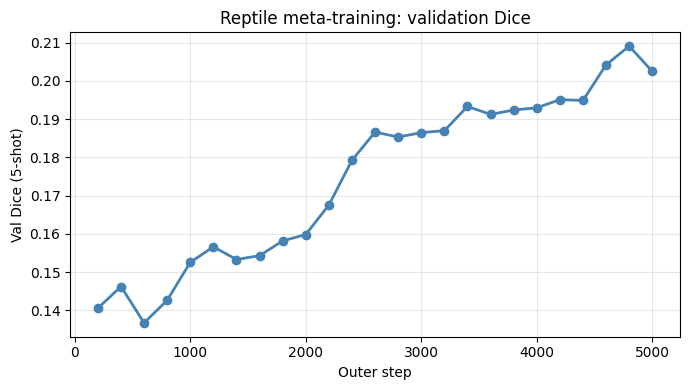

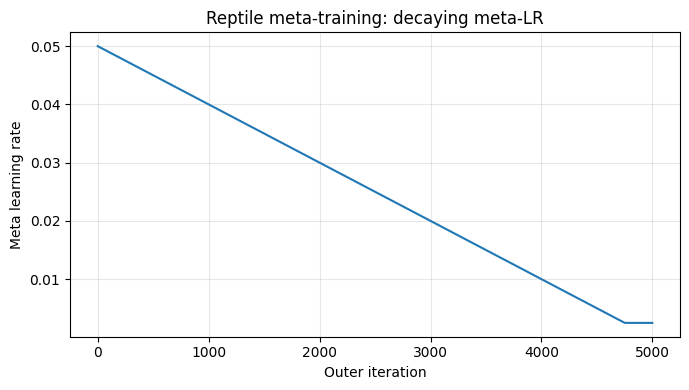

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1) Val Dice over outer steps
if meta_history["outer_step"]:
    plt.figure(figsize=(7, 4))
    plt.plot(meta_history["outer_step"], meta_history["val_dice"],
             marker="o", linewidth=2, color="steelblue")
    plt.xlabel("Outer step")
    plt.ylabel("Val Dice (5-shot)")
    plt.title("Reptile meta-training: validation Dice")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("meta_training_val_dice.png", dpi=150)
    plt.show()

# 2) Meta-LR decay plot
if "meta_lr" in meta_history and meta_history["meta_lr"]:
    plt.figure(figsize=(7, 4))
    plt.plot(meta_history["meta_lr"])
    plt.xlabel("Outer iteration")
    plt.ylabel("Meta learning rate")
    plt.title("Reptile meta-training: decaying meta-LR")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("meta_training_meta_lr.png", dpi=150)
    plt.show()

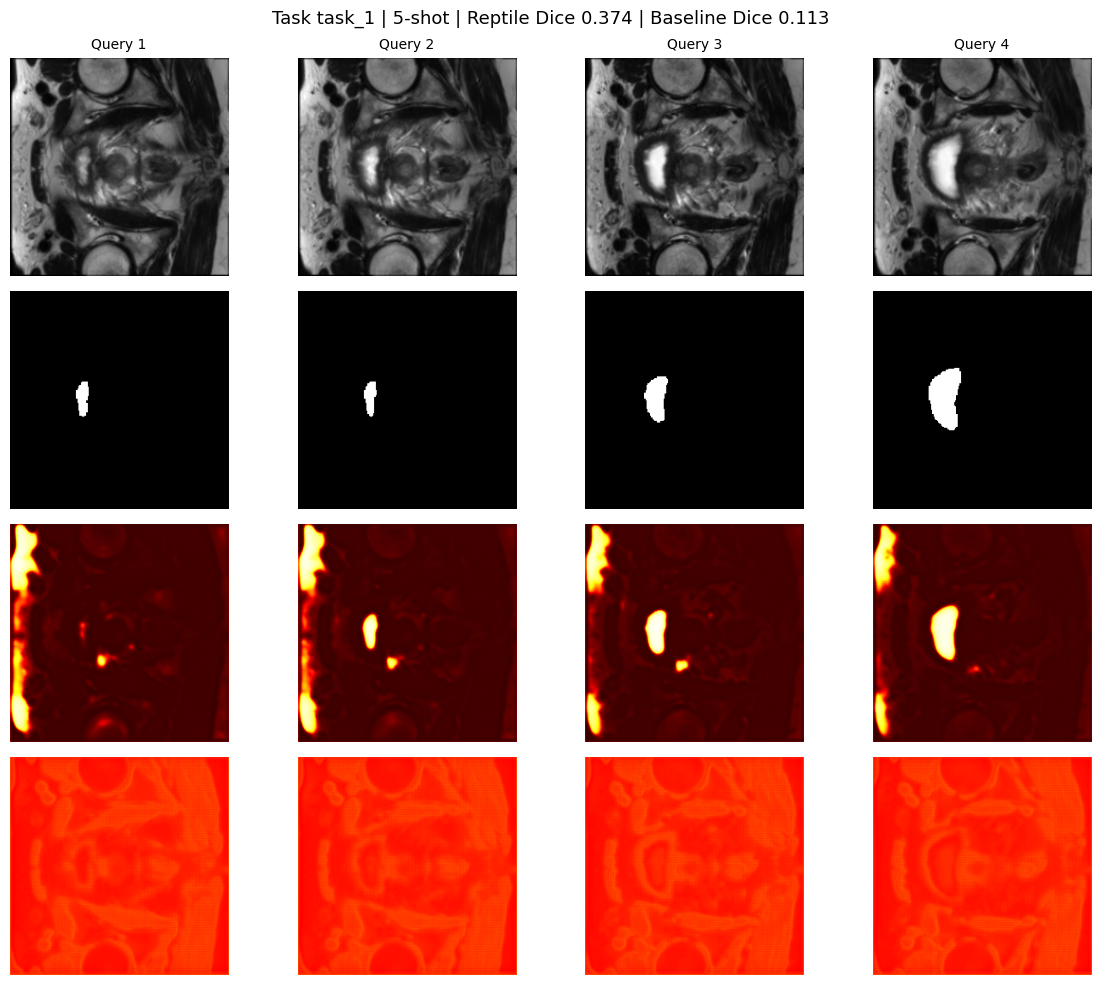

Saved qualitative_task_1_nshot5.png


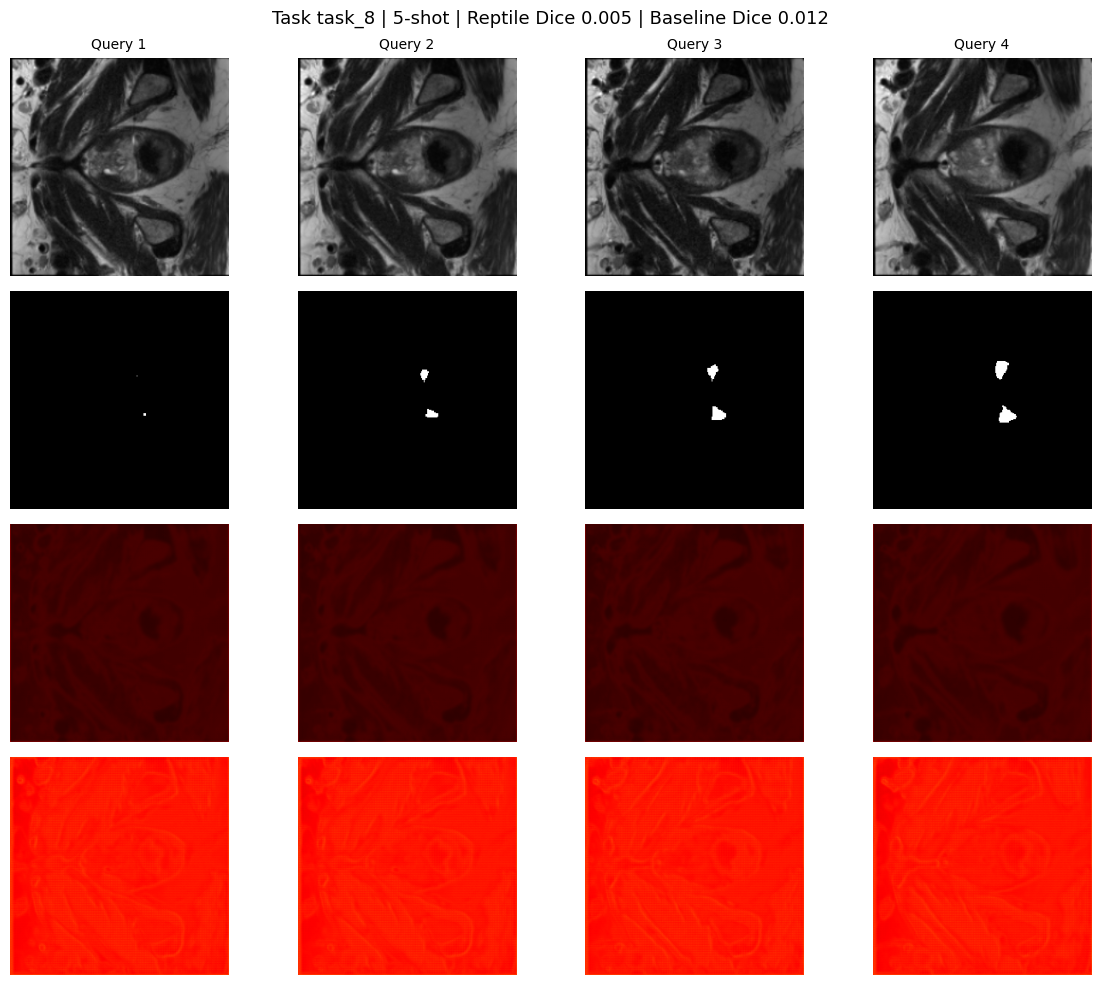

Saved qualitative_task_8_nshot5.png


In [14]:
def qualitative_panel(meta_model, task_dict, task_name,
                      n_shot=5, adapt_steps=20, seed=42, n_cols=4):
    """
    Show: image | GT | Reptile prediction | Baseline prediction (for same query).
    """
    r_dice, adapted_meta, episode = adapt_and_evaluate(
        meta_model, task_dict,
        n_shot=n_shot,
        adapt_steps=adapt_steps,
        adapt_lr=1e-3,
        seed=seed,
    )

    base = UNet().to(DEVICE)
    b_dice, adapted_base, _ = unified_adapt_and_evaluate(
        base,
        task_dict,
        n_shot=n_shot,
        epochs=20,
        lr=1e-3,
        seed=seed,
    )

    q_loader = episode.query_loader(batch_size=n_cols)
    # 1. Filter query slices (NEW)
    all_imgs, all_masks = [], []
    for imgs_b, masks_b in q_loader:
        for i in range(imgs_b.shape[0]):
            if masks_b[i].sum() > 0:
                all_imgs.append(imgs_b[i])
                all_masks.append(masks_b[i])
        if len(all_imgs) >= n_cols:
            break

    if len(all_imgs) == 0:
        print(f"[{task_name}] No query images with foreground masks available.")
        return

    imgs_b  = torch.stack(all_imgs[:n_cols]).to(DEVICE)
    masks_b = torch.stack(all_masks[:n_cols]).to(DEVICE)

    # 2. Run inference (KEEP UNCHANGED)
    adapted_meta.eval()
    adapted_base.eval()
    with torch.no_grad():
        preds_r = adapted_meta(imgs_b).cpu().numpy()
        preds_b = adapted_base(imgs_b).cpu().numpy()
        imgs_np = imgs_b.cpu().numpy()
        masks_np = masks_b.cpu().numpy()

    n = min(n_cols, imgs_np.shape[0])
    fig, axes = plt.subplots(4, n, figsize=(3 * n, 10))
    fig.suptitle(
        f"Task {task_name} | {n_shot}-shot "
        f"| Reptile Dice {r_dice:.3f} | Baseline Dice {b_dice:.3f}",
        fontsize=13,
    )

    row_labels = ["MR image", "Ground truth", "Reptile prediction", "Baseline prediction"]
    for row, label in enumerate(row_labels):
        axes[row, 0].set_ylabel(label, fontsize=11)

    for col in range(n):
        axes[0, col].imshow(imgs_np[col, 0], cmap="gray")
        axes[0, col].set_title(f"Query {col+1}", fontsize=10)
        axes[0, col].axis("off")

        axes[1, col].imshow(masks_np[col, 0] * 255, cmap="gray", vmin=0, vmax=255)
        axes[1, col].axis("off")

        axes[2, col].imshow(preds_r[col, 0], cmap="hot", vmin=0, vmax=1)
        axes[2, col].axis("off")

        axes[3, col].imshow(preds_b[col, 0], cmap="hot", vmin=0, vmax=1)
        axes[3, col].axis("off")

    plt.tight_layout()
    out_name = f"qualitative_{task_name}_nshot{n_shot}.png"
    plt.savefig(out_name, dpi=150)
    plt.show()
    print(f"Saved {out_name}")


# Generate qualitative panels for all test tasks at 5-shot
for t_name, t_dict in test_tasks.items():
    qualitative_panel(meta_model, t_dict, t_name, n_shot=5, adapt_steps=20)

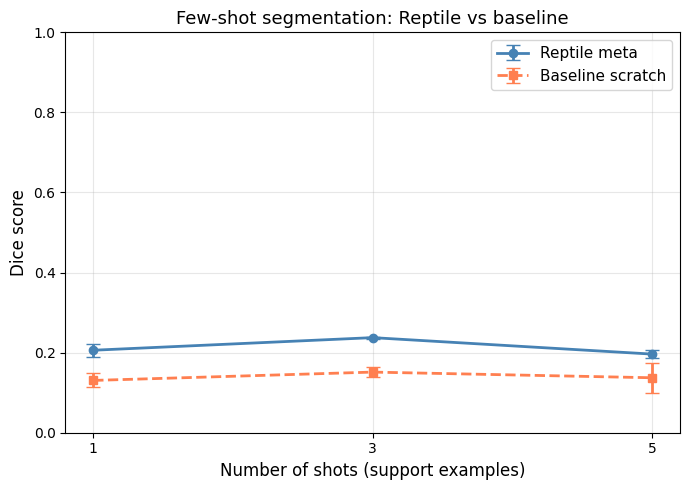

In [15]:
shots = sorted(results.keys())
rmeans = [np.mean(results[s]["reptile"]) for s in shots]
rstds  = [np.std(results[s]["reptile"])  for s in shots]
bmeans = [np.mean(results[s]["baseline"]) for s in shots]
bstds  = [np.std(results[s]["baseline"])  for s in shots]

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(
    shots, rmeans, yerr=rstds,
    marker="o", linewidth=2, capsize=5,
    label="Reptile meta", color="steelblue",
)
ax.errorbar(
    shots, bmeans, yerr=bstds,
    marker="s", linewidth=2, capsize=5,
    linestyle="--",
    label="Baseline scratch", color="coral",
)
ax.set_xlabel("Number of shots (support examples)", fontsize=12)
ax.set_ylabel("Dice score", fontsize=12)
ax.set_title("Few-shot segmentation: Reptile vs baseline", fontsize=13)
ax.set_xticks(shots)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("few_shot_results.png", dpi=150)
plt.show()

In [ ]:
import os
import json
import zipfile
from datetime import datetime

os.makedirs("results", exist_ok=True)
os.makedirs("temp", exist_ok=True)  # for any display-only images if needed

# Compute max Dice across all runs for naming
all_dice = []
for n_shot, vals in results.items():
    all_dice.extend(vals["reptile"])
    all_dice.extend(vals["baseline"])
max_dice = max(all_dice) if all_dice else 0.0

stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
zip_name = f"G8_BaseRepCompare_{N_OUTER}iters_{ADAPT_STEPS}steps_{max_dice:.4f}dice_{stamp}.zip"
zip_path = os.path.join("results", zip_name)

summary = {
    "n_outer": N_OUTER,
    "k_inner": K_INNER,
    "inner_lr": INNER_LR,
    "meta_lr": META_LR,
    "adapt_steps": ADAPT_STEPS,
    "baseline_epochs": BASELINE_EPOCHS,
    "device": DEVICE,
    "results": results,
}

summary_name = f"summary_EMS741_{stamp}.json"
summary_path = os.path.join("temp", summary_name)
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

files_to_pack = [
    "meta_model.pth",
    "meta_training_val_dice.png",
    "few_shot_results.png",
    "few_shot_summary.csv",
    "meta_training_meta_lr.png",
    summary_path,
]

# Optional: add qualitative panels if they exist
for fname in os.listdir("."):
    if fname.startswith("qualitative_") and fname.endswith(".png"):
        files_to_pack.append(os.path.join(".", fname))

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for f in files_to_pack:
        if os.path.exists(f):
            # store without leading ./ or temp/
            arcname = os.path.basename(f)
            z.write(f, arcname)

print("Created", zip_path)

Created results/G8_BaseRepCompare_5000iters_30steps_0.2401dice_20260328_214920.zip
